In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from matplotlib.lines import Line2D
import seaborn as sns


BASE_DIR = Path().resolve().parent
DATA_PROCESSED = BASE_DIR / "data" / "processed"

indicadores_concelho = pd.read_parquet(DATA_PROCESSED / "indicadores_concelho_15mais.parquet")

indicadores_concelho.head()

,cod_geografia,geografia,pop_15mais_total,pop_sem_escolaridade,pop_ensino_basico,pop_ensino_superior,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais,distrito
0,0101,Águeda,40563,2176,23116,5882,5.36,56.99,14.50,Aveiro
1,0102,Albergaria-a-Velha,21649,1054,12386,2989,4.87,57.21,13.81,Aveiro
2,0103,Anadia,24571,1705,13680,3862,6.94,55.68,15.72,Aveiro
3,0104,Arouca,18472,1371,11401,2115,7.42,61.72,11.45,Aveiro
4,0105,Aveiro,70463,2650,30472,19867,3.76,43.25,28.19,Aveiro


In [2]:
features = [
    "pct_sem_escolaridade_15mais",
    "pct_ensino_basico_15mais",
    "pct_ensino_superior_15mais"
]

df_cluster = indicadores_concelho[[
    "cod_geografia",
    "geografia",
    "distrito",
    "pop_15mais_total"
] + features].copy()

df_cluster.head()

,cod_geografia,geografia,distrito,pop_15mais_total,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais
0,0101,Águeda,Aveiro,40563,5.36,56.99,14.50
1,0102,Albergaria-a-Velha,Aveiro,21649,4.87,57.21,13.81
2,0103,Anadia,Aveiro,24571,6.94,55.68,15.72
3,0104,Arouca,Aveiro,18472,7.42,61.72,11.45
4,0105,Aveiro,Aveiro,70463,3.76,43.25,28.19


In [3]:
df_cluster[features].isna().sum()

pct_sem_escolaridade_15mais    0
pct_ensino_basico_15mais       0
pct_ensino_superior_15mais     0
dtype: int64

In [4]:
df_cluster[features].describe().round(2)

,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais
count,308.00,308.00,308.00
mean,8.31,55.64,13.80
std,2.98,6.04,5.16
min,3.15,32.58,5.77
25%,5.86,52.77,10.29
50%,8.07,56.54,12.40
75%,10.58,60.00,15.71
max,17.16,66.17,41.19


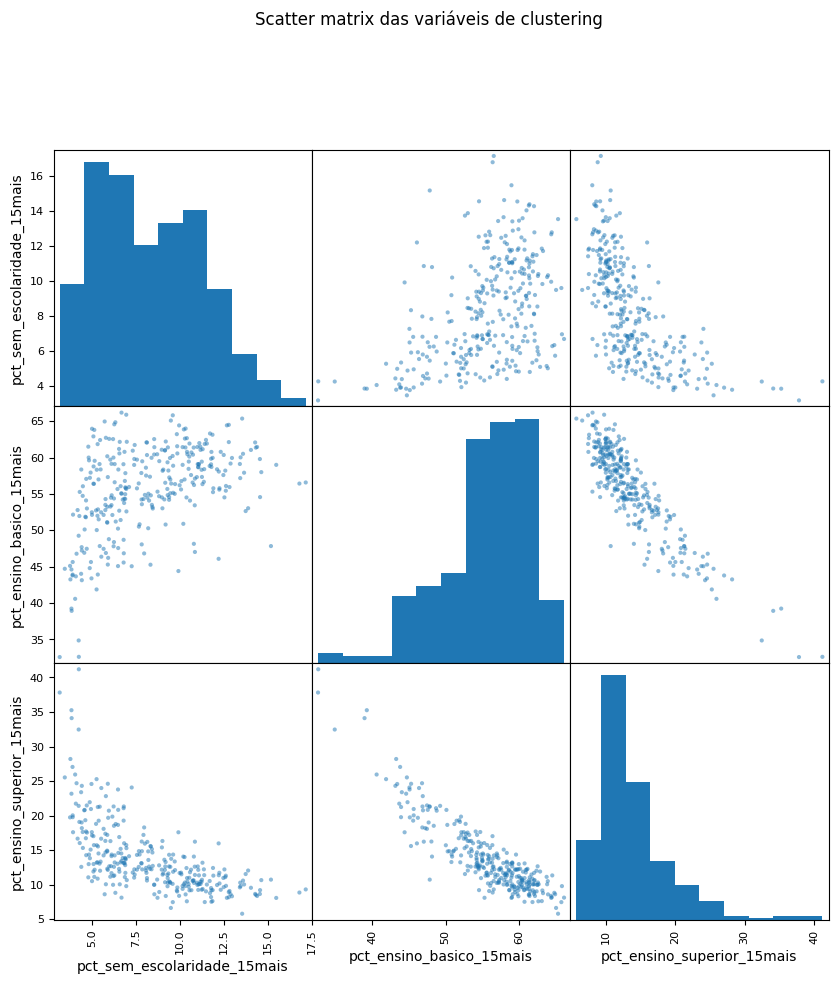

In [5]:
pd.plotting.scatter_matrix(
    df_cluster[features],
    figsize=(10, 10),
    diagonal="hist"
)

plt.suptitle("Scatter matrix das variáveis de clustering", y=1.02)
plt.show()

pela leitura dos scatterplots, k=2 tenderá a captar a clivagem principal; mas k=3 pode captar melhor a nuance territorial. cotovlo e silhueta para validar

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_cluster[features])

X_scaled[:5]

array([[-9.89577179e-01,  2.23361318e-01,  1.36503013e-01],
       [-1.15414324e+00,  2.59828472e-01,  2.51557444e-03],
       [-4.58935608e-01,  6.21599214e-03,  3.73408339e-01],
       [-2.97728042e-01,  1.00740513e+00, -4.55760303e-01],
       [-1.52693573e+00, -2.05417820e+00,  2.79489147e+00]])

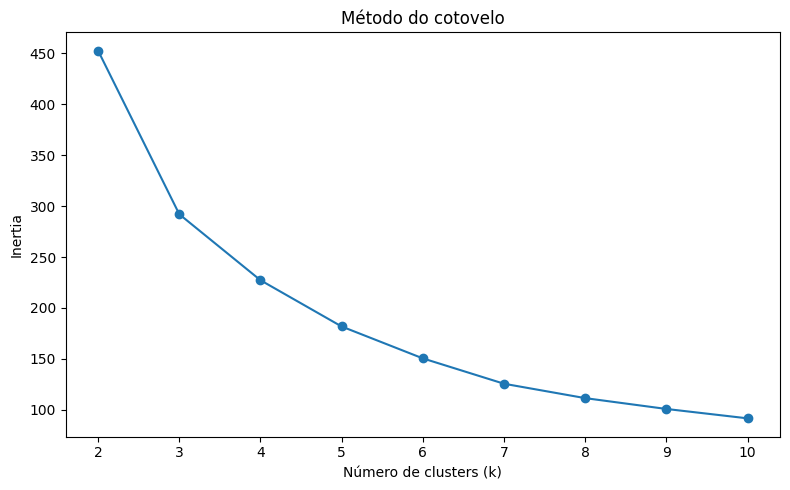

In [7]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inertia")
plt.title("Método do cotovelo")
plt.tight_layout()
plt.show()

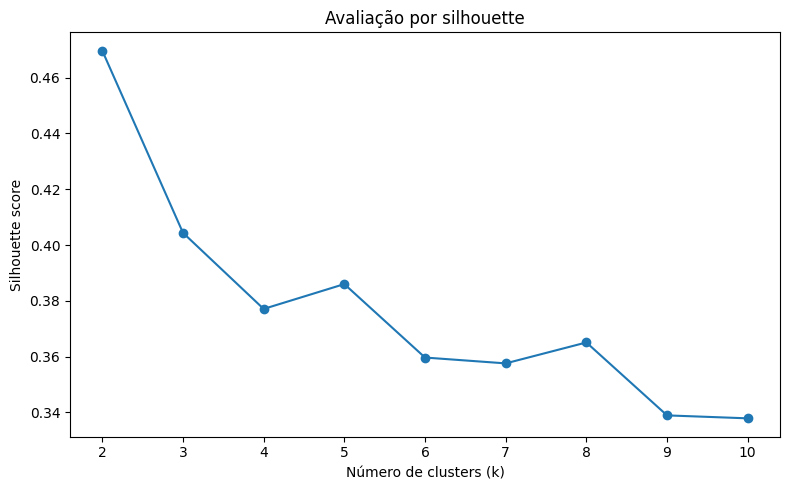

In [8]:
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_scores, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Avaliação por silhouette")
plt.tight_layout()
plt.show()

In [9]:
avaliacao_k = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

avaliacao_k.round(4)

,k,inertia,silhouette_score
0,2,452.5598,0.4696
1,3,292.0310,0.4044
2,4,227.2699,0.3771
3,5,181.8406,0.3860
4,6,150.5451,0.3597
5,7,125.6517,0.3576
6,8,111.5276,0.3651
7,9,100.8954,0.3390
8,10,91.6854,0.3379


Cotovelo claramente a definir 3 clusters. Silhueta a enveredar tecnicamente para uma separação forte entre dois grandes perfis, mas ainda admitem uma segmentação em três grupos com utilidade interpretativa

Com 3 clusters é muito provável que se consigam concelhos mais qualificados, concelhos intermédios econcelhos mais frágeis.

Isso é muito mais útil para interpretar analítica e narrativamemnte

In [10]:
# Adjust K-means with k=3

k_final = 3

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_cluster["cluster_k3"] = kmeans.fit_predict(X_scaled)

df_cluster.head()

,cod_geografia,geografia,distrito,pop_15mais_total,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais,cluster_k3
0,0101,Águeda,Aveiro,40563,5.36,56.99,14.50,1
1,0102,Albergaria-a-Velha,Aveiro,21649,4.87,57.21,13.81,1
2,0103,Anadia,Aveiro,24571,6.94,55.68,15.72,1
3,0104,Arouca,Aveiro,18472,7.42,61.72,11.45,1
4,0105,Aveiro,Aveiro,70463,3.76,43.25,28.19,2


In [11]:
# Clusters dimension by k= 3 - k-means
df_cluster["cluster_k3"].value_counts().sort_index()

cluster_k3
0    124
1    132
2     52
Name: count, dtype: int64

In [12]:
# clusters profile

perfil_clusters = (
    df_cluster
    .groupby("cluster_k3")[features + ["pop_15mais_total"]]
    .mean()
    .round(2)
)

perfil_clusters

,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais,pop_15mais_total
cluster_k3,,,,
0,11.29,59.11,10.13,7728.88
1,6.72,56.39,13.68,25298.36
2,5.22,45.48,22.83,90656.04


In [13]:
# clusters order by superior education percentage

perfil_clusters_ordenado = perfil_clusters.sort_values(
    "pct_ensino_superior_15mais",
    ascending=False
)

perfil_clusters_ordenado

,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais,pop_15mais_total
cluster_k3,,,,
2,5.22,45.48,22.83,90656.04
1,6.72,56.39,13.68,25298.36
0,11.29,59.11,10.13,7728.88


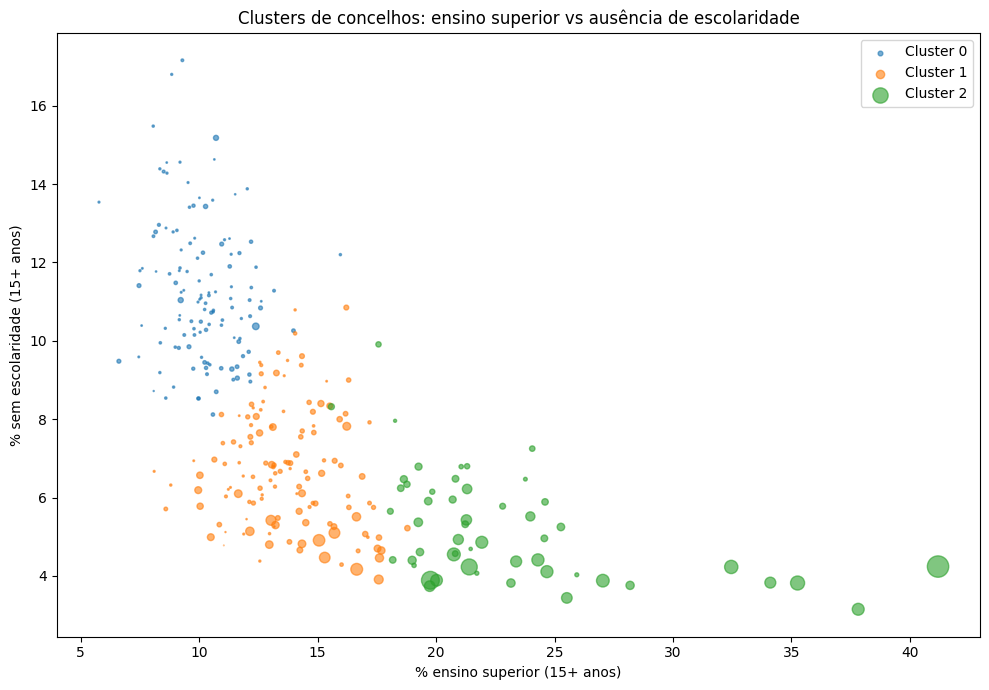

In [14]:
plt.figure(figsize=(10, 7))

for cluster_id in sorted(df_cluster["cluster_k3"].unique()):
    subset = df_cluster[df_cluster["cluster_k3"] == cluster_id]
    plt.scatter(
        subset["pct_ensino_superior_15mais"],
        subset["pct_sem_escolaridade_15mais"],
        s=subset["pop_15mais_total"] / 2000,
        alpha=0.6,
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("% ensino superior (15+ anos)")
plt.ylabel("% sem escolaridade (15+ anos)")
plt.title("Clusters de concelhos: ensino superior vs ausência de escolaridade")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
clusters_concelho = df_cluster[[
    "cod_geografia",
    "geografia",
    "distrito",
    "pop_15mais_total",
    "pct_sem_escolaridade_15mais",
    "pct_ensino_basico_15mais",
    "pct_ensino_superior_15mais",
    "cluster_k3"
]].copy()

clusters_concelho.head()

,cod_geografia,geografia,distrito,pop_15mais_total,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais,cluster_k3
0,0101,Águeda,Aveiro,40563,5.36,56.99,14.50,1
1,0102,Albergaria-a-Velha,Aveiro,21649,4.87,57.21,13.81,1
2,0103,Anadia,Aveiro,24571,6.94,55.68,15.72,1
3,0104,Arouca,Aveiro,18472,7.42,61.72,11.45,1
4,0105,Aveiro,Aveiro,70463,3.76,43.25,28.19,2


In [16]:
clusters_concelho.to_parquet(DATA_PROCESSED / "clusters_concelho_k3.parquet", index=False)

print("Tabela de clusters por concelho guardada com sucesso.")

Tabela de clusters por concelho guardada com sucesso.



Cluster 0 — concelhos com perfil educativo mais frágil, caracterizados por maior incidência de população sem escolaridade, forte peso do ensino básico e reduzida presença de ensino superior.

Cluster 1 — concelhos com perfil intermédio, com níveis de ausência de escolaridade relativamente mais baixos, ensino básico ainda dominante e presença moderada de ensino superior.

Cluster 2 — concelhos mais qualificados, com maior peso relativo do ensino superior, menor incidência de ausência de escolaridade e menor dependência relativa do ensino básico

apesar de o ensino básico ser dominante em todos os clusters, o seu peso relativo diminui claramente nos concelhos mais qualificados e aumenta nos mais frágeis

Cluster 0 → Baixa qualificação

Cluster 1 → Qualificação intermédia

Cluster 2 → Alta qualificação

A segmentação foi inicialmente efetuada com KMeans, sendo posteriormente comparada com um método hierárquico de Ward, com o objetivo de avaliar a consistência estrutural dos grupos obtidos.

In [17]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [18]:
Z = linkage(X_scaled, method="ward")

Z[:5]

array([[2.00000000e+02, 2.29000000e+02, 2.53651522e-02, 2.00000000e+00],
       [7.80000000e+01, 1.46000000e+02, 2.78593618e-02, 2.00000000e+00],
       [1.17000000e+02, 2.45000000e+02, 4.17201235e-02, 2.00000000e+00],
       [5.80000000e+01, 2.51000000e+02, 4.24838920e-02, 2.00000000e+00],
       [1.90000000e+01, 2.81000000e+02, 4.44254124e-02, 2.00000000e+00]])

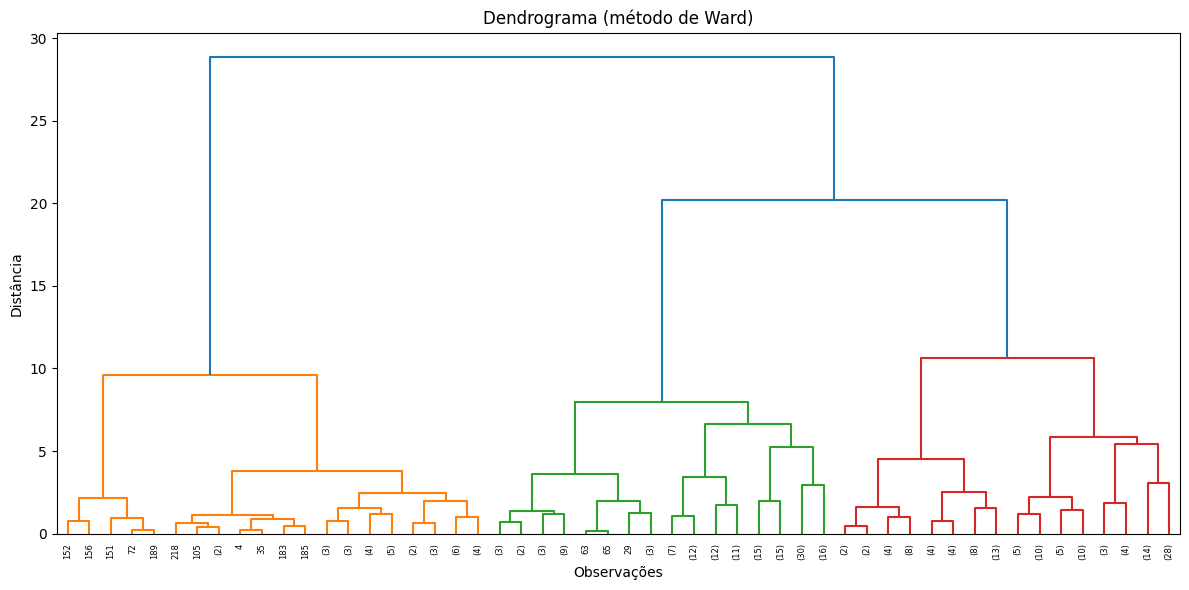

In [19]:
# dendogram


plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode="level",  # limita profundidade
    p=5                     # número de níveis a mostrar
)

plt.title("Dendrograma (método de Ward)")
plt.xlabel("Observações")
plt.ylabel("Distância")
plt.tight_layout()
plt.show()

In [20]:
# Create clusters Ward (k=3)

df_cluster["cluster_ward_k3"] = fcluster(Z, t=3, criterion="maxclust") - 1

df_cluster.head()

,cod_geografia,geografia,distrito,pop_15mais_total,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais,cluster_k3,cluster_ward_k3
0,0101,Águeda,Aveiro,40563,5.36,56.99,14.50,1,2
1,0102,Albergaria-a-Velha,Aveiro,21649,4.87,57.21,13.81,1,2
2,0103,Anadia,Aveiro,24571,6.94,55.68,15.72,1,2
3,0104,Arouca,Aveiro,18472,7.42,61.72,11.45,1,1
4,0105,Aveiro,Aveiro,70463,3.76,43.25,28.19,2,0


In [21]:
# Clusters distribution Ward

df_cluster["cluster_ward_k3"].value_counts().sort_index()

cluster_ward_k3
0     43
1    141
2    124
Name: count, dtype: int64

In [22]:
# Ward Clusters profile

perfil_ward = (
    df_cluster
    .groupby("cluster_ward_k3")[features + ["pop_15mais_total"]]
    .mean()
    .round(2)
)

perfil_ward

,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais,pop_15mais_total
cluster_ward_k3,,,,
0,4.93,44.64,23.74,101459.37
1,10.93,59.02,10.40,8357.55
2,6.49,55.61,14.22,27989.60


In [23]:
# Sort Clusters by superior education percentage

perfil_ward_ordenado = perfil_ward.sort_values(
    "pct_ensino_superior_15mais",
    ascending=False
)

perfil_ward_ordenado

,pct_sem_escolaridade_15mais,pct_ensino_basico_15mais,pct_ensino_superior_15mais,pop_15mais_total
cluster_ward_k3,,,,
0,4.93,44.64,23.74,101459.37
2,6.49,55.61,14.22,27989.60
1,10.93,59.02,10.40,8357.55


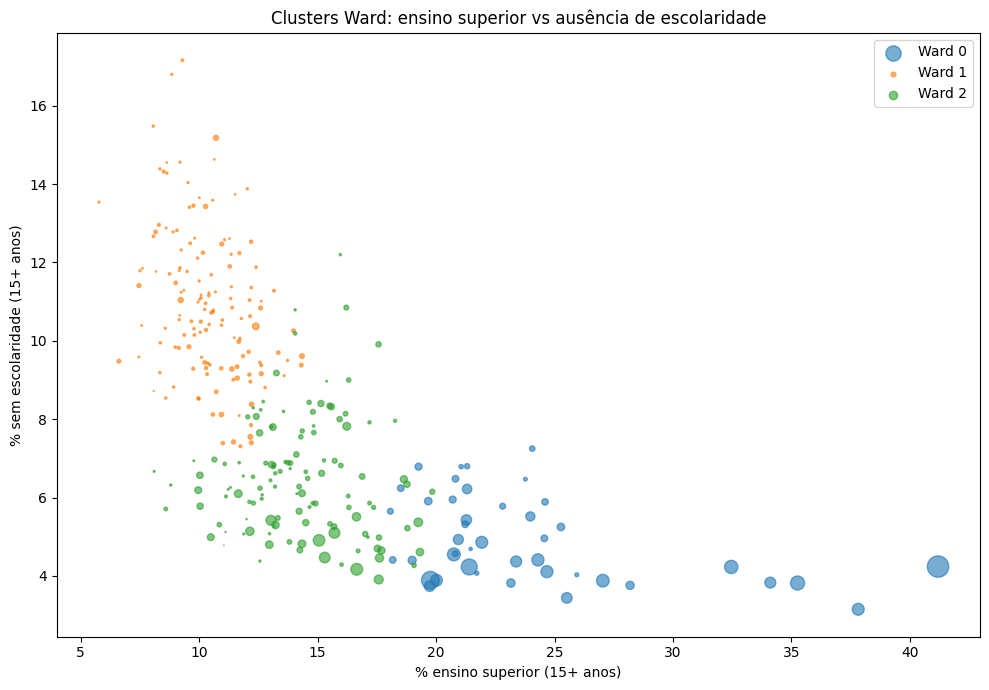

In [24]:
plt.figure(figsize=(10, 7))

for cluster_id in sorted(df_cluster["cluster_ward_k3"].unique()):
    subset = df_cluster[df_cluster["cluster_ward_k3"] == cluster_id]
    plt.scatter(
        subset["pct_ensino_superior_15mais"],
        subset["pct_sem_escolaridade_15mais"],
        s=subset["pop_15mais_total"] / 2000,
        alpha=0.6,
        label=f"Ward {cluster_id}"
    )

plt.xlabel("% ensino superior (15+ anos)")
plt.ylabel("% sem escolaridade (15+ anos)")
plt.title("Clusters Ward: ensino superior vs ausência de escolaridade")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# comaprison ward - k- means

comparacao = pd.crosstab(
    df_cluster["cluster_k3"],
    df_cluster["cluster_ward_k3"]
)

print(comparacao)

map_kmeans_to_ward = {
    0: 1,
    1: 2,
    2: 0
}

cluster_ward_k3   0    1    2
cluster_k3                   
0                 0  123    1
1                 0   18  114
2                43    0    9


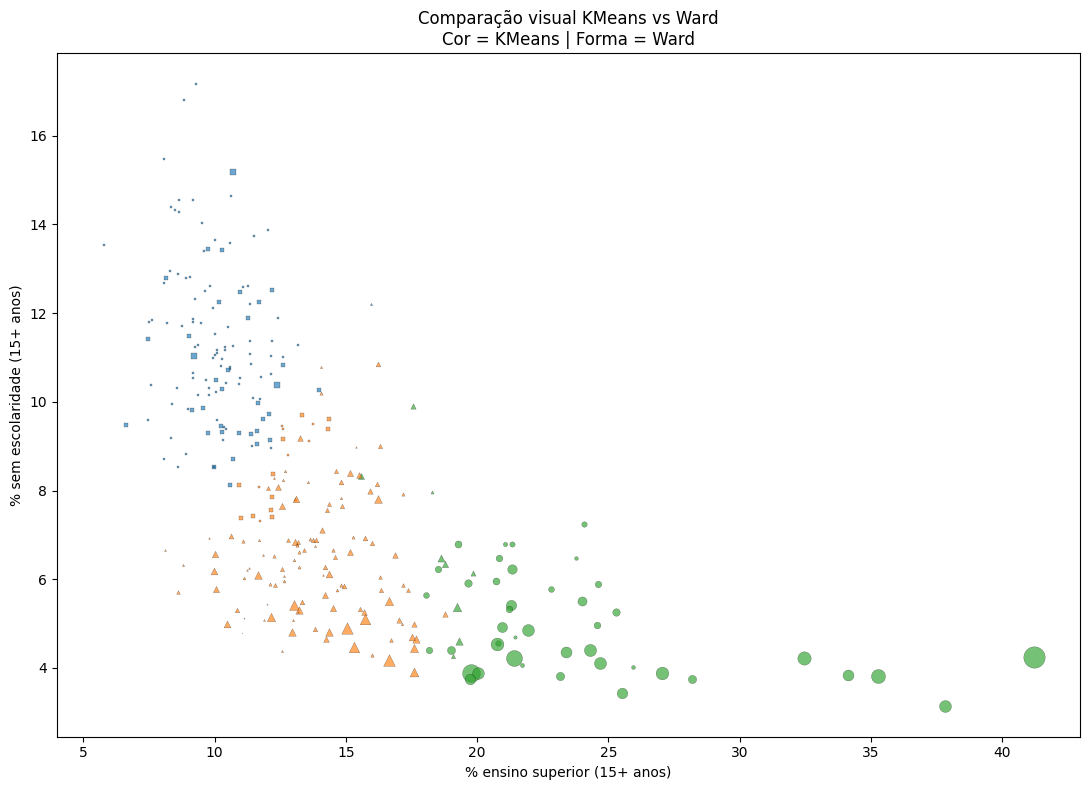

In [26]:
# cópia de trabalho
df_compare = df_cluster.copy()

# mapas visuais
color_map = {
    0: "#1f77b4",  # azul
    1: "#ff7f0e",  # laranja
    2: "#2ca02c"   # verde
}

marker_map = {
    0: "o",   # círculo
    1: "s",   # quadrado
    2: "^"    # triângulo
}

plt.figure(figsize=(11, 8))

for _, row in df_compare.iterrows():
    plt.scatter(
        row["pct_ensino_superior_15mais"],
        row["pct_sem_escolaridade_15mais"],
        s=row["pop_15mais_total"] / 2000,
        c=color_map[row["cluster_k3"]],
        marker=marker_map[row["cluster_ward_k3"]],
        alpha=0.65,
        edgecolors="black",
        linewidths=0.2
    )

plt.xlabel("% ensino superior (15+ anos)")
plt.ylabel("% sem escolaridade (15+ anos)")
plt.title("Comparação visual KMeans vs Ward\nCor = KMeans | Forma = Ward")
plt.tight_layout()
plt.show()

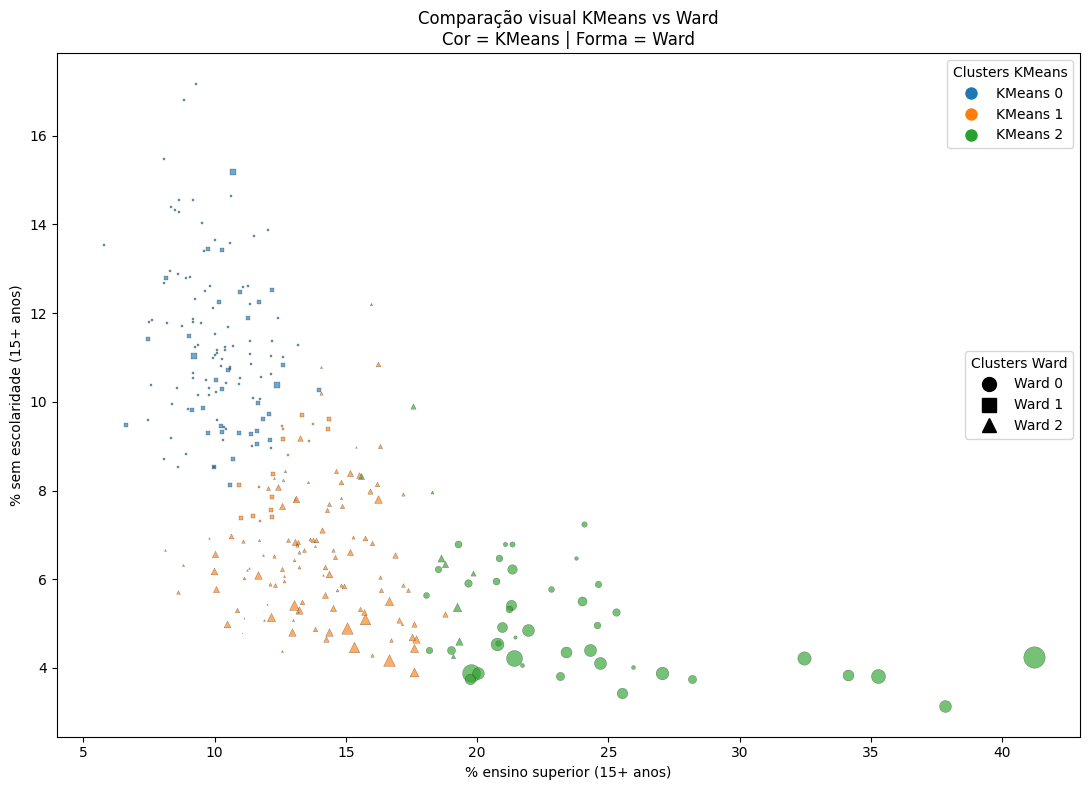

In [27]:
# scatterplot comparison between ward and k-means

legend_kmeans = [
    Line2D([0], [0], marker='o', color='w', label='KMeans 0', markerfacecolor=color_map[0], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='KMeans 1', markerfacecolor=color_map[1], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='KMeans 2', markerfacecolor=color_map[2], markersize=10)
]

legend_ward = [
    Line2D([0], [0], marker=marker_map[0], color='black', label='Ward 0', linestyle='None', markersize=10),
    Line2D([0], [0], marker=marker_map[1], color='black', label='Ward 1', linestyle='None', markersize=10),
    Line2D([0], [0], marker=marker_map[2], color='black', label='Ward 2', linestyle='None', markersize=10)
]

plt.figure(figsize=(11, 8))

for _, row in df_compare.iterrows():
    plt.scatter(
        row["pct_ensino_superior_15mais"],
        row["pct_sem_escolaridade_15mais"],
        s=row["pop_15mais_total"] / 2000,
        c=color_map[row["cluster_k3"]],
        marker=marker_map[row["cluster_ward_k3"]],
        alpha=0.65,
        edgecolors="black",
        linewidths=0.2
    )

plt.xlabel("% ensino superior (15+ anos)")
plt.ylabel("% sem escolaridade (15+ anos)")
plt.title("Comparação visual KMeans vs Ward\nCor = KMeans | Forma = Ward")

leg1 = plt.legend(handles=legend_kmeans, title="Clusters KMeans", loc="upper right")
plt.gca().add_artist(leg1)
plt.legend(handles=legend_ward, title="Clusters Ward", loc="center right")

plt.tight_layout()
plt.show()

A comparação entre KMeans e o método hierárquico de Ward revela uma elevada consistência na segmentação dos concelhos, com concordância em cerca de 91% dos casos. As discrepâncias observadas concentram-se em concelhos com perfis intermédios ou de transição, sugerindo que os clusters identificados refletem uma estrutura territorial real e não apenas um artefacto do algoritmo utilizado.

Com base no KMeans e validado por Ward, temos três grupos claros:

Cluster 0 — Baixa qualificação
maior ausência de escolaridade;
forte peso do ensino básico;
menor presença de ensino superior.

Cluster 1 — Qualificação intermédia
ausência de escolaridade moderada;
ensino básico ainda dominante;
algum peso de ensino superior.

Cluster 2 — Maior qualificação
menor ausência de escolaridade;
maior peso relativo de ensino superior;
menor dependência do ensino básico.

In [28]:
# create label for clusters
cluster_labels = {
    0: "Baixa qualificação",
    1: "Qualificação intermédia",
    2: "Maior qualificação"
}

df_cluster["cluster_label"] = df_cluster["cluster_k3"].map(cluster_labels)

df_cluster[["geografia", "distrito", "cluster_k3", "cluster_label"]].head()

,geografia,distrito,cluster_k3,cluster_label
0,Águeda,Aveiro,1,Qualificação intermédia
1,Albergaria-a-Velha,Aveiro,1,Qualificação intermédia
2,Anadia,Aveiro,1,Qualificação intermédia
3,Arouca,Aveiro,1,Qualificação intermédia
4,Aveiro,Aveiro,2,Maior qualificação


In [29]:
# save final table with clusters

clusters_concelho = df_cluster[[
    "cod_geografia",
    "geografia",
    "distrito",
    "pop_15mais_total",
    "pct_sem_escolaridade_15mais",
    "pct_ensino_basico_15mais",
    "pct_ensino_superior_15mais",
    "cluster_k3",
    "cluster_label",
    "cluster_ward_k3"
]].copy()

clusters_concelho.to_parquet(DATA_PROCESSED / "clusters_concelho_k3.parquet", index=False)

print("Tabela final de clusters guardada com sucesso.")

Tabela final de clusters guardada com sucesso.


Conclusão da clusterização

A aplicação do algoritmo KMeans permitiu segmentar os concelhos portugueses em três grupos com perfis educativos distintos: um grupo de menor qualificação, um grupo intermédio e um grupo de maior qualificação. A comparação com o método hierárquico de Ward revelou uma elevada consistência entre as duas abordagens, com concordância em cerca de 91% dos concelhos, reforçando a robustez da solução adotada.

Os clusters obtidos refletem uma clivagem territorial clara:

concelhos com maior fragilidade educativa, marcados por maior ausência de escolaridade e forte predominância do ensino básico;
concelhos intermédios, com melhoria relativa dos indicadores;
concelhos mais qualificados, caracterizados por maior peso do ensino superior e níveis reduzidos de ausência de escolaridade.

As discrepâncias entre métodos concentram-se em concelhos de perfil intermédio ou híbrido, o que é consistente com a existência de territórios de transição entre os perfis mais extremos.

A segmentação dos concelhos portugueses com base em indicadores educativos da população com 15 ou mais anos permitiu identificar três perfis territoriais distintos: um grupo de menor qualificação, um grupo intermédio e um grupo de maior qualificação.

A solução com 3 clusters, obtida por KMeans, revelou-se analiticamente interpretável, distinguindo:

concelhos com maior incidência de população sem escolaridade e forte predominância do ensino básico;
concelhos com perfil intermédio;
concelhos com maior peso relativo de ensino superior e menor ausência de escolaridade.

A comparação com o método hierárquico de Ward confirmou a robustez desta segmentação, com elevada concordância entre os dois métodos. As discrepâncias observadas concentraram-se sobretudo em concelhos com perfil intermédio ou de transição, o que reforça a ideia de que os clusters identificados refletem uma estrutura territorial real e não apenas um efeito do algoritmo utilizado.

Em termos substantivos, os resultados apontam para uma clivagem clara entre territórios mais qualificados, tendencialmente associados a áreas urbanas e metropolitanas, e territórios mais frágeis do ponto de vista educativo, frequentemente ligados ao interior e a contextos de envelhecimento demográfico.